# Dialogue Summarization: Prompt Engineering Across Model Scale

Compares **zero-shot / one-shot / few-shot** prompting for dialogue
summarization on [DialogSum](https://huggingface.co/datasets/knkarthick/dialogsum),
across **FLAN-T5-base** and **FLAN-T5-large**, scored with ROUGE-1/2/L.

Reuses the `src/` package from the companion GitHub repo, so results here
match the numbers reported in the repo's README.

> **Kaggle setup:** enable **Internet** under *Notebook Settings* (needed to
> clone the repo and download the models/dataset from Hugging Face).

In [1]:
# Install pinned dependencies
!pip install -q transformers==4.40.0 datasets==2.19.0 rouge-score==0.1.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 1.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 32.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.7 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, 

In [1]:
# Clone the project repo and make src/ importable.
# Replace the URL below if you rename or fork the repo.
import sys, subprocess, pathlib

REPO_URL = "https://github.com/shimaaelbana/Dialogue-Summarization-Prompt-Engineering-Across-LLM-Models-Scale.git"
REPO_DIR = pathlib.Path("Dialogue-Summarization-Prompt-Engineering-Across-LLM-Models-Scale")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

sys.path.append(str(REPO_DIR.resolve()))

Cloning into 'Dialogue-Summarization-Prompt-Engineering-Across-LLM-Models-Scale'...


In [2]:
from src.pipeline import run_experiment

MODEL_NAMES = ["google/flan-t5-base", "google/flan-t5-large"]

# Held-out evaluation indices, disjoint from the few-shot exemplar indices
# ([40, 80, 120]) used inside src/pipeline.py's SHOT_CONFIGS.
TEST_INDICES = [200, 250, 300, 350, 400]

In [3]:
results_df = run_experiment(
    model_names=MODEL_NAMES,
    test_indices=TEST_INDICES,
)
results_df

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/11.3M [00:00<?, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/12460 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

,model,shot_config,rouge1,rouge2,rougeL
0,google/flan-t5-base,zero-shot,0.299643,0.078332,0.238964
1,google/flan-t5-base,one-shot,0.302492,0.078998,0.241243
2,google/flan-t5-base,few-shot,0.295249,0.083024,0.248150
3,google/flan-t5-large,zero-shot,0.315625,0.100000,0.242808
4,google/flan-t5-large,one-shot,0.319821,0.116667,0.242532
5,google/flan-t5-large,few-shot,0.328576,0.126423,0.253750


In [4]:
import os

os.makedirs("results", exist_ok=True)
results_df.to_csv("results/results.csv", index=False)
print("Saved results/results.csv")

Saved results/results.csv


## Visualize: ROUGE-L by model and shot config

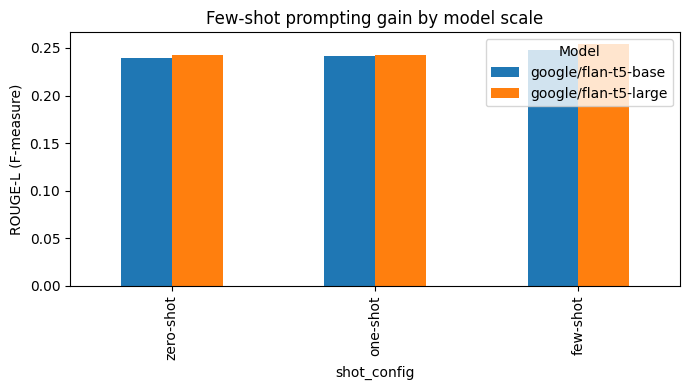

In [5]:
import matplotlib.pyplot as plt

pivot = results_df.pivot(index="shot_config", columns="model", values="rougeL")
pivot = pivot.reindex(["zero-shot", "one-shot", "few-shot"])

ax = pivot.plot(kind="bar", figsize=(7, 4))
ax.set_ylabel("ROUGE-L (F-measure)")
ax.set_title("Few-shot prompting gain by model scale")
ax.legend(title="Model")
plt.tight_layout()
plt.savefig("results/rougeL_by_shot_config.png", dpi=150)
plt.show()

## Findings

_Fill this in after running the cells above:_

- Does few-shot prompting help `flan-t5-base` as much as it helps
  `flan-t5-large`?
- Where does the ROUGE-L curve start to flatten out as you add exemplars?
- Any qualitative failure cases worth showing (e.g. hallucinated details,
  truncated summaries)?

Paste 2-3 example generations below to make the notebook self-explanatory
for a reader who doesn't want to re-run it.

In [6]:
# Optional: show a couple of qualitative examples side by side.
from src.data import load_dialogsum
from src.generate import summarize
from src.prompting import build_few_shot_prompt

dataset = load_dialogsum()
example_idx = TEST_INDICES[0]
dialogue = dataset["test"][example_idx]["dialogue"]
reference = dataset["test"][example_idx]["summary"]

for model_name in MODEL_NAMES:
    prompt = build_few_shot_prompt(dataset, "test", [40, 80, 120], dialogue)
    prediction = summarize(prompt, model_name)
    print(f"=== {model_name} (few-shot) ===")
    print("Reference:", reference)
    print("Prediction:", prediction)
    print()

=== google/flan-t5-base (few-shot) ===
Reference: #Person1# teaches #Person2# how to upgrade software and hardware in #Person2#'s system.
Prediction: #Person1 wants to upgrade his system. #Person2 wants to add a painting program to his software. #Person1 wants to upgrade his hardware.

=== google/flan-t5-large (few-shot) ===
Reference: #Person1# teaches #Person2# how to upgrade software and hardware in #Person2#'s system.
Prediction: Person2 is considering upgrading her system. She needs a faster processor, a faster hard disc, more memory and a faster modem. She doesn't have a CD-ROM drive.

